# Financial Model Calibration using ANNs (CaNN, Calibration Neural Network) (Heston model)
###### This Jupyter Notebook implements the calibration framework proposed in "A neural network-based framework for financial model calibration", Liu et al. ([1]) building on "Pricing options and computing implied volatilities using neural networks", Liu et al. ([2]) as part of my master's thesis. It extends the implementation at https://github.com/Redmek/Pricing-options-and-computing-implied-volatilities-using-neural-networks and merges two seperate ANNs (one for option prices and one for implied volatilies) into a single network for fast calibration.

###### Author: Dominik Wirsig

# -------------------------------------------------------




## The framework consists of 3 Phases, i.e.:

### 1. Training (FORWARD PASS)
### 2. Prediction (FORWARD PASS)
### 3. Calibration (BACKWARD PASS)

# -------------------------------------------------------




Table of contents

### 1) Forward pass
###### a) Preperation
###### b) Data generation
###### c) Training Heston-IV-ANN
###### d) Prediction

### 2) Backward pass
###### a) Calibration of all 5 Heston parameters
###### b) Calibration of only 3 Heston parameters (kappa, v0 fixed)


# -------------------------------------------------------




# 1) Forward pass




## a) Preperation




In [2]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

from scipy.optimize import differential_evolution

In [3]:
# run on GPU
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


### Black-Scholes




In [4]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S:     spot price
  K:     strike price
  T:     time to maturity
  t:     spot time
  r:     interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

##### Defining class Heston-IV-ANN

In [5]:
class Heston_ANN(nn.Module):
  def __init__(self):
    """
    Initilize Heston-IV-ANN netwwork with four hidden layers. 
    Same architecture as the one used in Table (2) [2].
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(Heston_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(8, 200)
    self.fc2 = nn.Linear(200, 200)
    self.fc3 = nn.Linear(200, 200)
    self.fc4 = nn.Linear(200, 200)
    self.fc5 = nn.Linear(200, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight) 
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = F.mse_loss(output, target)
      train_loss += loss.item() * data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += F.mse_loss(output, target, reduction = 'sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss

## b) Data generation

### Numerical method here: Heston and COS

#### COS Method

#### Vanilla call coefficients

$\begin{aligned} \chi_{k}(c, d):=& \frac{1}{1+\left(\frac{k \pi}{b-a}\right)^{2}}\left[\cos \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\cos \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right.\\ &\left.+\frac{k \pi}{b-a} \sin \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\frac{k \pi}{b-a} \sin \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right] \end{aligned}$

$\psi_{k}(c, d):= \begin{cases}{\left[\sin \left(k \pi \frac{d-a}{b-a}\right)-\sin \left(k \pi \frac{c-a}{b-a}\right)\right] \frac{b-a}{k \pi},} & k \neq 0, \\ (d-c), & k=0 .\end{cases}$

$V_{k}^{\text {call }}=\frac{2}{b-a} K\left(\chi_{k}(0, b)-\psi_{k}(0, b)\right)$

In [6]:
def call_cosine_coef(a, b, c, d, K, N):
  """
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  K: Strike.
  N: summing lenght.
  Returns V_k coefficient for call option.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*K*(chi_k-psi_k)

In [7]:
def call_cosine_coef_moy(a, b, c, d, N):
  """
  Moyeness version.
  Coefficient V_k for plain vanilla options. 
  Section 3.1, equations (22) and (23).
  a, b, c, d: truncation range parameters.
  N: summing lenght.
  Returns V_k coefficient for call option devided by K.
  """
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

#### Charateristic function for Heston model

$\begin{aligned} \varphi_{h e s}\left(\omega ; u_{0}\right)=& \exp \left(i \omega \mu \Delta t+\frac{u_{0}}{\eta^{2}}\left(\frac{1-e^{-D \Delta t}}{1-G e^{-D \Delta t}}\right)(\lambda-i \rho \eta \omega-D)\right) \\ & \cdot \exp \left(\frac{\lambda \bar{u}}{\eta^{2}}\left(\Delta t(\lambda-i \rho \eta \omega-D)-2 \log \left(\frac{1-G e^{-D \Delta t}}{1-G}\right)\right)\right) \end{aligned}$

$D=\sqrt{(\lambda-i \rho \eta \omega)^{2}+\left(\omega^{2}+i \omega\right) \eta^{2}} \quad$ and $\quad G=\frac{\lambda-i \rho \eta \omega-D}{\lambda-i \rho \eta \omega+D} $

In [8]:
def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  """
  Characteristic function of the log-asset price following the Heston model.
  Section 3.3, equation (33).
  a, b: truncation range parameters.
  N: summing lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns Charateristic function vector.
  """
  #if kappa < 1e-4:
  #  print("kapp < 1e-4")
  #  kappa = 1e-5
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi


#### Heston cumulants

$c_{1}=\mu T+\left(1-e^{-\lambda T}\right) \frac{\bar{u}-u_{0}}{2 \lambda}-\frac{1}{2} \bar{u} T$

$\begin{aligned} c_{2}=& \frac{1}{8 \lambda^{3}}\left(\eta T \lambda e^{-\lambda T}\left(u_{0}-\bar{u}\right)(8 \lambda \rho-4 \eta)\right.\\ &+\lambda \rho \eta\left(1-e^{-\lambda T}\right)\left(16 \bar{u}-8 u_{0}\right) \\ &+2 \bar{u} \lambda T\left(-4 \lambda \rho \eta+\eta^{2}+4 \lambda^{2}\right) \\ &+\eta^{2}\left(\left(\bar{u}-2 u_{0}\right) e^{-2 \lambda T}+\bar{u}\left(6 e^{-\lambda T}-7\right)+2 u_{0}\right) \\ &\left.+8 \lambda^{2}\left(u_{0}-\bar{u}\right)\left(1-e^{-\lambda T}\right)\right) \end{aligned}$

In [9]:
def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  """
  Computes Heston cumulants as defined in the appendix A for the Heston model.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  Returns cumulants c1 and c2.
  """

  #if kappa == 0:
  #  c1 = r * tau + tau * (vbar - v0) / 2 - 0.5 * vbar * tau
  #else: 
  #   c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau


  #safe_kappa = np.max(kappa, 1e-5)
  safe_kappa = kappa
  c2 = 0.125 / safe_kappa ** 3 * (gamma * tau * np.exp(- safe_kappa * tau) * (v0 - vbar) * (8 * safe_kappa * rho - 4 * gamma) + \
     safe_kappa * rho * gamma * (1 - np.exp(- safe_kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * safe_kappa * tau * (- 4 * safe_kappa * rho * gamma + gamma ** 2 + 4 * safe_kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * safe_kappa * tau) + vbar * (6 * np.exp(- safe_kappa * tau) - 7) + 2 * v0) + \
     8 * safe_kappa ** 2 * (v0 - vbar) * (1 - np.exp(-safe_kappa * tau)))
  return c1, c2

#### Truncation range

$[a, b]:=\left[c_{1}-L \sqrt{c_{2}+\sqrt{c_{4}}}, \quad c_{1}+L \sqrt{c_{2}+\sqrt{c_{4}}}\right]$

In [10]:
def Truncation_range(c1, c2, c4, L):
  """
  Computes the truncation range given the cumulants c1, c2, c4 and the truncation lenght L.
  c1, c2, c4: Model cumulants.
  L: truncation lenght.
  Returns tuncation interval sup b and inf a.
  """
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

#### Exponential coefficient

$e^{i k \pi \frac{\mathbf{x}-a}{b-a}}$

In [11]:
def exponential_coef(a, b, N, S0, K):
  """
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  S0: asset initial price.
  K: strike.
  Returns the exponential coefficient vector.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(S0/K)-a)/(b-a))

In [12]:
def exponential_coef_moy(a, b, N, moyeness):
  """
  Moyeness version.
  Computes the exponential coefficient used in the final pricing sum.
  a, b: truncation range.
  N: sum lenght.
  moyeness: S/K.
  Returns the exponential coefficient vector devided by K.
  """
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

#### Vanilla call price

$v\left(\mathbf{x}, t_{0}, u_{0}\right) \approx \mathbf{K} e^{-r \Delta t} \cdot \operatorname{Re}\left\{\sum_{k=0}^{N-1} \varphi_{h e s}\left(\frac{k \pi}{b-a} ; u_{0}\right) U_{k} \cdot e^{i k \pi \frac{\mathbf{x}-a}{b-a}}\right\}$

In [13]:
def call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, K, S0 ):
  """
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  S0: asset initial price.
  K: strike.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef(a, b, c, d, K, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef(a, b, N, S0, K)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [14]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, K = K, S0 = S0)

True


array([[29.79261082]])

In [15]:
def call_option_Heston_moy(N, L, r, tau, kappa, gamma, vbar, v0, rho, moyeness ):
  """
  Moyeness version.
  Computes call option price using COS method.
  N: sum lenght.
  L: truncation lenght.
  r: risk free rate.
  tau: time to maturity.
  kappa: reversion speed .
  gamma: Vol of vol.
  vbar: Long average variance.
  v0: Initial variance.
  rho: Correlation.
  moyeness: S/K.
  Returns option price.
  """
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef_moy(a, b, c, d, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef_moy(a, b, N, moyeness)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [16]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston_moy(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = 1)

True


array([[0.29792611]])

# Latin Hypercube Sampling

### Generating Data

#### Sampling range for the Heston parameters (Table (3) in [1])

In [18]:
# here Table (3) of [1] is used, kappa is numerically sensitive to small values
eps = 1e-2 # is used to generate open intervals
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .05+eps, .0+eps, -0.9+eps, 0.4+eps, .01+eps, .01+eps, .05+eps], u_bounds = [1.4-eps, 3.0-eps, .05-eps, 0.0-eps, 3.0-eps, .5-eps, .8-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d = 8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5] <= sample[:,6]**2)
  sample = np.delete(sample, indecies, 0)
  hs_prices = call_option_Heston_moy(N = 500, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa = sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  #hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))

  # hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f}, {:.2f}]".format(sample[:,0].min(), sample[:,0].max()))
  print("Tau.......... [{:.2f}, {:.2f}]".format(sample[:,1].min(), sample[:,1].max()))
  print("r............ [{:.2f}, {:.2f}]".format(sample[:,2].min(), sample[:,2].max()))
  print("Corr ........ [{:.2f}, {:.2f}]".format(sample[:,3].min(), sample[:,3].max()))
  print("Kappa........ [{:.2f}, {:.2f}]".format(sample[:,4].min(), sample[:,4].max()))
  print("V_bar........ [{:.2f}, {:.2f}]".format(sample[:,5].min(), sample[:,5].max()))
  print("Gamma........ [{:.2f}, {:.2f}]".format(sample[:,6].min(), sample[:,6].max()))
  print("V_0 ......... [{:.2f}, {:.2f}]".format(sample[:,7].min(), sample[:,7].max()))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f}, {:.2f}]".format(hs_prices.min(), hs_prices.max()))

  return sample, hs_prices

## c) Training Heston-IV-ANN

### Use Brent to inverse price to implied volatility (IV)

In [17]:
from scipy import optimize

def calcimpliedvol(dataset):
    """
    Computes the implied volatilities using the brent method.
    dataset: numpy array containing moneyness, time to maturity, risk free interest rate and V/K.
    Returns a vector of implied volatilities.
    """
    money = np.array(dataset[0])
    T = np.array(dataset[1])
    r = np.array(dataset[2])
    marketoptionPrice = np.array(dataset[3])
    def bs_price(sigma):
      d1 = ( np.log(money) + (r + 0.5 * sigma ** 2) * (T) ) / (sigma * np.sqrt(T))
      d2 = d1 - sigma*np.sqrt(T)
      value_moyeness = money * norm.cdf(d1) - np.exp(-r * (T)) * norm.cdf(d2) 
      fx = value_moyeness - marketoptionPrice
      return fx
    return optimize.brentq(bs_price, -1, 1, maxiter=100)



### Generate data and add IV to get the final training data set

In [23]:
sample, hs_prices = Heston_LHS_data_generator(n = 10**5)

# Combine required inputs for Brent
brent_input = np.concatenate([sample[:, [0, 1, 2]], hs_prices], axis=1)  # shape (n, 4)

#print("brent_input shape:", brent_input.shape)

# Apply Brent row by row
implied_vols = np.array([
    calcimpliedvol(row) for row in brent_input
])

#print("V_0 ......... [{:.2f}, {:.2f}]".format(sample[:,7].min(), sample[:,7].max()))
print("------ ANN OUTPUT ------")

print("Black-scholes IV sigma.......... [{:.2f}, {:.2f}]".format(implied_vols.min(), implied_vols.max()))

# Filter out NaNs
valid_idx = ~np.isnan(implied_vols)
sample = sample[valid_idx]
implied_vols = implied_vols[valid_idx]

# Recombine into final dataset (input + IV target)
final_dataset = np.concatenate([sample, implied_vols.reshape(-1, 1)], axis=1)

# Convert to torch Tensor
hs_dataset = torch.FloatTensor(final_dataset)


------ INPUT ------
S/K.......... [0.61, 1.39]
Tau.......... [0.06, 2.99]
r............ [0.01, 0.04]
Corr ........ [-0.89, -0.01]
Kappa........ [0.41, 2.99]
V_bar........ [0.02, 0.49]
Gamma........ [0.02, 0.79]
V_0 ......... [0.06, 0.49]
------ OUTPUT ------
V/K.......... [-0.00, 0.77]
------ ANN OUTPUT ------
Black-scholes IV sigma.......... [0.00, 0.74]


### Training of the ANN

In [21]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}


use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
hs_dataset = hs_dataset
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "ANN_weights/HESTON_IV_ANN.pt")
    

cuda
Train Epoch: 1 [0/77478 (0%)]	log Loss: -0.814654

Train set: Average log loss: -2.9490


Test set: Average loss: -4.9763

Current Learning rate 0.0001
Train Epoch: 2 [0/77478 (0%)]	log Loss: -4.947230

Train set: Average log loss: -5.3119


Test set: Average loss: -5.9893

Current Learning rate 0.0001
Train Epoch: 3 [0/77478 (0%)]	log Loss: -5.962725

Train set: Average log loss: -6.6269


Test set: Average loss: -7.2201

Current Learning rate 0.0001
Train Epoch: 4 [0/77478 (0%)]	log Loss: -7.247884

Train set: Average log loss: -7.4967


Test set: Average loss: -7.8282

Current Learning rate 0.0001
Train Epoch: 5 [0/77478 (0%)]	log Loss: -7.836086

Train set: Average log loss: -7.9839


Test set: Average loss: -8.2073

Current Learning rate 0.0001
Train Epoch: 6 [0/77478 (0%)]	log Loss: -8.222159

Train set: Average log loss: -8.3124


Test set: Average loss: -8.5013

Current Learning rate 0.0001
Train Epoch: 7 [0/77478 (0%)]	log Loss: -8.528742

Train set: Average log loss: -8.

Training WIDE 6.363734419163629e-07 VS in the article 8.04e-09


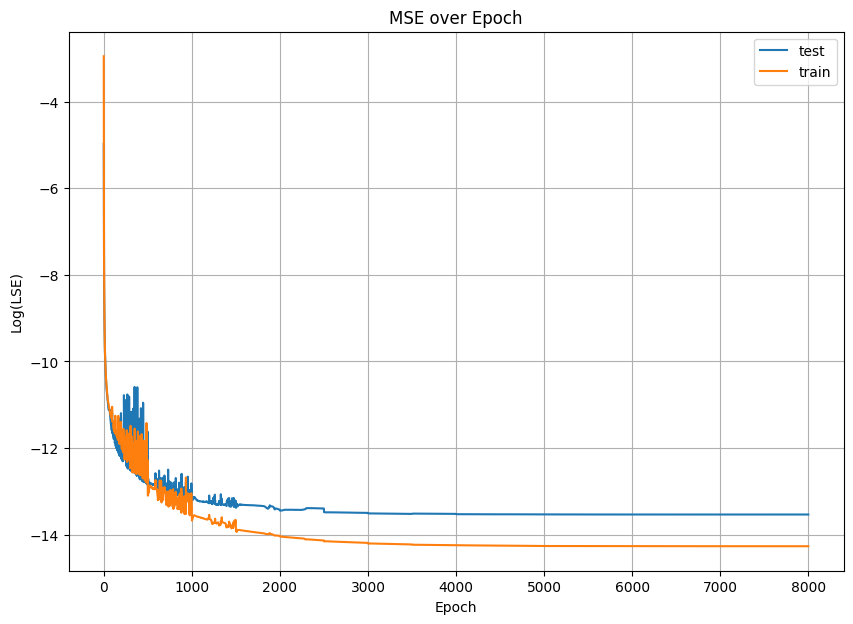

In [22]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

## d) Prediction
#### Load the ANN

In [18]:
# Loading model
device = 'cuda'
loaded_Heston_IV_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/HESTON_IV_ANN.pt"
loaded_Heston_IV_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_IV_ANN.eval()


Heston_ANN(
  (fc1): Linear(in_features=8, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=200, bias=True)
  (fc4): Linear(in_features=200, out_features=200, bias=True)
  (fc5): Linear(in_features=200, out_features=1, bias=True)
)

#### This table shows similar trained forward performance as shown in Table (4) from [1]

In [25]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.363491e-07
MAE 6.223580e-04
MAPE 1.346766e-03
R2 9.999357e-01
-----------Test scores----------------
MSE 1.323949e-06
MAE 7.818849e-04
MAPE 1.727188e-03
R2 9.998636e-01


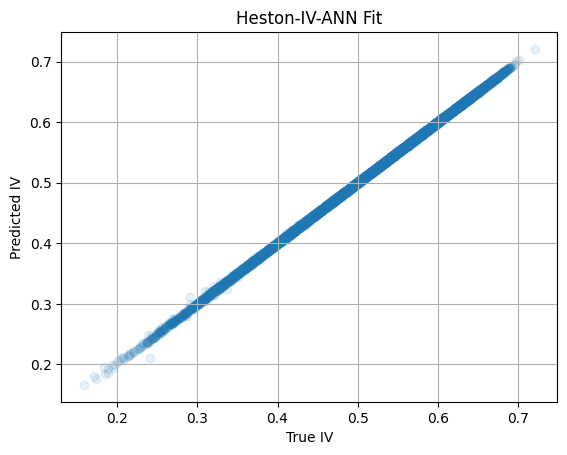

In [26]:

plt.scatter(targets, outputs, alpha=0.1)
plt.xlabel("True IV")
plt.ylabel("Predicted IV")
plt.title("Heston-IV-ANN Fit")
plt.grid(True)
plt.show()


# 2) Backward pass

### Reference parameters

In [19]:
# Section 4.1.1 in [1]
T = 2 
S0 = 100
kappa = 0.1
gamma = 0.1  
v_bar = 0.1
rho = -0.75
v0 = 0.05
r = 0.05

### CaNN search space

In [ ]:
# Parameter ranges for the 5D Heston grid (Table 6 in [1])
rho_min,  rho_max  = -0.75, -0.25
kappa_min,kappa_max=  0.5,   1.0
vbar_min, vbar_max =  0.15,  0.35
gamma_min,gamma_max=  0.3,  0.5
v0_min,   v0_max   =  0.15,  0.35

# 5 equidistant values for each parameter within the specified bounds
rho_vals   = np.linspace(rho_min,   rho_max,   5)
kappa_vals = np.linspace(kappa_min, kappa_max, 5)
vbar_vals  = np.linspace(vbar_min,  vbar_max,  5)
gamma_vals = np.linspace(gamma_min, gamma_max, 5)
v0_vals    = np.linspace(v0_min,    v0_max,    5)

# Build full 5D grid: shape (5, 5, 5, 5, 5)
R, K, VBAR, G, V0 = np.meshgrid(rho_vals, kappa_vals, vbar_vals, gamma_vals, v0_vals, indexing="ij")

# Stack into a (3125, 5) array:
# each row = one parameter vector [rho, kappa, v̄, gamma, v0]
param_grid = np.stack([R, K, VBAR, G, V0], axis=-1).reshape(-1, 5)

print(param_grid.shape)  # (3125, 5)


(3125, 5)


## a) Calibration of all 5 Heston parameters




### Objective function

In [ ]:
# Equation (19) in [1]

def calibration_objective(theta, inputs, market_iv, iv_ann):
    # theta: [rho, kappa, vbar, gamma, v0]
    # inputs: [moneyness, maturity, r] fixed per quote
    input_tensor = torch.tensor(np.column_stack([
        inputs,  # shape (N, 3)
        np.tile(theta, (inputs.shape[0], 1))
    ]), dtype=torch.float32).to(device)

    with torch.no_grad():
        pred_iv = iv_ann(input_tensor).cpu().numpy().flatten()

    reg = (1e-6 * np.sum(np.abs(theta)))
    return np.mean((pred_iv - market_iv) ** 2) + reg


In [22]:
iv_ann = loaded_Heston_IV_ANN         # the trained ANN will be passed in the DE function


### Synthetic calibration data  (five equally spaced points between the lower and upper bound for each parameter, 5^5 = 3125 combinations in total) 

In [ ]:
# Fixed (moneyness, maturity) grid: 5 × 7 = 35 synthetic market quotes per case
moneyness = np.linspace(0.85, 1.15, 5)
maturity  = np.linspace(0.5, 2.0, 7)
S0 = 100.0
r  = 0.03

# Storage for parameter errors and objective values over all test cases
all_abs_errors_5 = []
all_J_values_5 = []  

for i, (rho, kappa, vbar, gamma, v0) in enumerate(param_grid, start=1):
    # True Heston parameter vector for this test case
    theta_true = np.array([rho, kappa, vbar, gamma, v0])

    # --- generate 35 synthetic "market" IV quotes for theta_true ---
    market_quotes = []
    for tau in maturity:
        for m in moneyness:
            # Heston call price under theta_true
            price = call_option_Heston_moy(500, 12, r, tau, kappa, gamma, vbar, v0, rho, m)
            # Invert price to implied volatility
            iv    = calcimpliedvol([m, tau, r, price])
            # Store tuple (m, tau, r, iv)
            market_quotes.append((m, tau, r, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]   # (m, tau, r)
    market_iv = market_quotes[:, 3]    # IVs

    # --- run DE calibration on CaNN parameter bounds (Table 6 region) ---
    result = differential_evolution(
        lambda theta: calibration_objective(theta, inputs, market_iv, iv_ann),
        bounds=[
            (rho_min,   rho_max),
            (kappa_min, kappa_max),
            (vbar_min,  vbar_max),
            (gamma_min, gamma_max),
            (v0_min,    v0_max),
        ],
        strategy="best1bin",
        popsize=10,      # 10 × number_of_parameters, as in the paper
    )

    theta_hat = result.x
    abs_err = np.abs(theta_hat - theta_true)
    all_abs_errors_5.append(abs_err)
    all_J_values_5.append(result.fun)

    #if i <= 3:  # just to see a few
    #    print(f"Case {i}/{len(param_grid)}")
    #    print(" true:", np.round(theta_true, 6))
    #    print(" hat: ", np.round(theta_hat, 6))
    #    print(" abs: ", np.round(abs_err, 6))
    #    print(" MSE: ", result.fun)

all_abs_errors_5 = np.array(all_abs_errors_5)
#print("Mean abs error over 3125 cases:", all_abs_errors_5.mean(axis=0))

### Averaged performance of the backward pass of the Heston-CaNN (5 parameters)

In [24]:
param_names = ["|rho-rho*|     =", "|kappa-kappa*| =", "|vbar-vbar*|   =", "|gamma-gamma*| =", "|v0-v0*|       ="]
mean_abs = all_abs_errors_5.mean(axis=0)  # shape (5,)


print("Absolute deviation from Theta*:\n")
for name, val in zip(param_names, mean_abs):
    print("  {} {:e}".format(name, val))


Absolute deviation from Theta*:

  |rho-rho*|     = 6.263268e-02
  |kappa-kappa*| = 1.230775e-01
  |vbar-vbar*|   = 8.615517e-03
  |gamma-gamma*| = 5.165077e-02
  |v0-v0*|       = 1.449650e-03


In [31]:
all_J_values = np.array(all_J_values_5)   # each entry is MJ for one surface
MJ_mean = all_J_values.mean()
N = market_iv.shape[0]  # 35
J_theta = MJ_mean * N

print("J(Theta): {:.6e}".format(J_theta))
print("MJ      : {:.6e}".format(MJ_mean))


J(Theta): 8.773513e-05
MJ      : 2.506718e-06


## b) Calibration of only 3 Heston parameters




### (kappa and v0 fixed)

In [ ]:
def calibration_objective_3(theta_3, inputs, market_iv, iv_ann, kappa_true, v0_true):
    """
    theta_3 : [rho, vbar, gamma]
    kappa_true, v0_true : fixed from the current test case
    inputs : (N, 3) with (m, tau, r)
    """
    rho, vbar, gamma = theta_3
    m   = inputs[:, 0].astype(np.float32)
    tau = inputs[:, 1].astype(np.float32)
    r   = inputs[:, 2].astype(np.float32)
    N   = inputs.shape[0]

    X = np.column_stack([
        m,
        tau,
        r,
        np.full(N, rho,         dtype=np.float32),
        np.full(N, kappa_true, dtype=np.float32),
        np.full(N, vbar,       dtype=np.float32),
        np.full(N, gamma,      dtype=np.float32),
        np.full(N, v0_true,    dtype=np.float32),
    ])

    x_tensor = torch.from_numpy(X).to(device)
    with torch.no_grad():
        pred_iv = iv_ann(x_tensor).cpu().numpy().ravel()

    diff = pred_iv - market_iv
    mse  = np.mean(diff**2)
    return mse 


In [27]:
bounds_3 = [
    (rho_min,  rho_max),
    (vbar_min, vbar_max),
    (gamma_min,gamma_max),
]

all_abs_errors_3 = []
all_J_values_3 = []  

for i, (rho_t, kappa_t, vbar_t, gamma_t, v0_t) in enumerate(param_grid, start=1):
    # ----- generate market quotes for the true parameter set -----
    market_quotes = []
    for tau in maturity:
        for m in moneyness:
            price = call_option_Heston_moy(500, 12, r, tau, kappa_t, gamma_t, vbar_t, v0_t, rho_t, m)
            iv    = calcimpliedvol([m, tau, r, price])
            market_quotes.append((m, tau, r, iv))

    market_quotes = np.array(market_quotes)
    inputs    = market_quotes[:, :3]
    market_iv = market_quotes[:, 3]

    # ----- DE only over (rho, vbar, gamma); kappa_t, v0_t fixed -----
    res = differential_evolution(
        lambda theta_3: calibration_objective_3(theta_3, inputs, market_iv, iv_ann,
                                               kappa_true=kappa_t, v0_true=v0_t),
        bounds=bounds_3,
        strategy="best1bin",
        popsize=15,      

    )

    theta_hat_3 = res.x
    theta_true_3 = np.array([rho_t, vbar_t, gamma_t])
    abs_err = np.abs(theta_hat_3 - theta_true_3)
    all_abs_errors_3.append(abs_err)
    all_J_values_3.append(result.fun)

    #if i <= 3:
    #    print(f"Case {i}/{len(param_grid)}")
    #    print(" true (rho,vbar,gamma):", theta_true_3)
    #    print(" hat  (rho,vbar,gamma):", theta_hat_3)
    #    print(" abs err:", abs_err)
    #    print(" MSE:    ", res.fun)

all_abs_errors_3 = np.array(all_abs_errors_3)
#mean_abs_err = all_abs_errors_3.mean(axis=0)
#print("Mean abs error [rho, vbar, gamma]:", mean_abs_err_3)


### Averaged performance of the backward pass of the Heston-CaNN (3 parameters)

In [ ]:
param_names = ["|rho-rho*|     =", "|vbar-vbar*|   =", "|gamma-gamma*| ="]
mean_abs = all_abs_errors_3.mean(axis=0)  # shape (5,)

print("Absolute deviation from Theta*:\n")
for name, val in zip(param_names, mean_abs):
    print("  {} {:e}".format(name, val))


Absolute deviation from Theta*:

  |rho-rho*|     = 4.622106e-02
  |vbar-vbar*|   = 4.454992e-03
  |gamma-gamma*| = 3.571812e-02


In [ ]:
all_J_values_3 = np.array(all_J_values_3)   # each entry is MJ for one surface
MJ_mean = all_J_values_3.mean()
N = market_iv.shape[0]  # 35
J_theta = MJ_mean * N

print("J(Theta): {:.6e}".format(J_theta))
print("MJ      : {:.6e}".format(MJ_mean))


J(Theta): 8.966551e-05
MJ      : 2.561872e-06
